# Regional time series

Spatial min / mean / max over predefined regions, plotted as a function of
rollout time. ERA5 is shown as black dashed mean with grey shading for the
min–max range.

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import sys
sys.path.insert(0, str(Path('..').resolve()))
from utils import VARS_LATEX

Parameters

In [ ]:
model_name = 'Aurora'
var        = '2m_temperature'   # variable name as stored in all_pred
Rt         = 7 * 4   # temporal downsampling (1 point per week)

list_areas = [
    'global', 'Arctic', 'Antarctic',
    'Europe', 'Australia-New Zealand', 'East Asia', 'North America',
]

# Local paths — update to your files; not released in the repo
pred_path = Path(f'/path/to/pred_{model_name}.nc')
era5_path = Path('/path/to/ERA5.zarr')

COLOR_MODEL = {
    'ERA5':         'black',
    'Aurora':       'tab:cyan',
    'SFNO':         'tab:green',
    'Pangu':        'tab:pink',
    'GraphCast':    'tab:purple',
    'FourCastNet':  'tab:olive',
    'FuXi':         'tab:brown',
    'AIFS':         'tab:red',
    'GenCast':      'tab:orange',
}

Region definitions

In [ ]:
# Longitudes in [0, 360]. Ranges that cross the antimeridian have lon_start > lon_end.
BOXES = {
    'global':               [0,     360,   -90,   90],
    'Tropics':              [0,     360,   -20,   20],
    'Northern hemisphere':  [0,     360,    20,   90],
    'Southern hemisphere':  [0,     360,   -90,  -20],
    'Europe':               [347.5,  42.5,  35,   75],
    'North America':        [240,   285,    25,   60],
    'North Atlantic':       [290,   340,    25,   60],
    'North Pacific':        [145,   230,    25,   60],
    'East Asia':            [110,   135,    24,   45],
    'Australia-New Zealand':[120,   175,   -45,  -12.5],
    'Arctic':               [0,     360,    60,   90],
    'Antarctic':            [0,     360,   -90,  -60],
    'Central Europe':       [5,      20,    45,   55],
    'Western US':           [235,   255,    30,   50],
    'Amazon':               [290,   315,   -15,    5],
    'Sahara':               [10,     25,    12,   22],
}


def select_box(area_name, ds):
    """Spatial subset for a named region. Handles antimeridian-crossing boxes."""
    lon0, lon1, lat0, lat1 = BOXES[area_name]
    if lon0 < lon1:
        ds_box = ds.sel(longitude=(ds.longitude >= lon0) & (ds.longitude <= lon1))
    else:  # wraps antimeridian
        ds_box = ds.sel(longitude=(ds.longitude >= lon0) | (ds.longitude <= lon1))
    return ds_box.sel(latitude=(ds_box.latitude >= lat0) & (ds_box.latitude <= lat1))

Labels

In [6]:
VAR_LABELS = {
    "2m_temperature":           ("T2m",  "K"),
    "10m_u_component_of_wind":  ("U10m", "m/s"),
    "10m_v_component_of_wind":  ("V10m", "m/s"),
    "mean_sea_level_pressure":  ("MSLP", "Pa"),
    "temperature_850":          ("T850", "K"),
    "u_component_of_wind_850":  ("U850", "m/s"),
    "v_component_of_wind_850":  ("V850", "m/s"),
    "geopotential_850":         ("Z850", "m²/s²"),
    "temperature_500":          ("T500", "K"),
    "specific_humidity_500":    ("Q500", "kg/kg"),
    "geopotential_500":         ("Z500", "m²/s²"),
    "temperature_300":          ("T300", "K"),
    "u_component_of_wind_300":  ("U300", "m/s"),
    "v_component_of_wind_300":  ("V300", "m/s"),
    "temperature_100":          ("T100", "K"),
    "specific_humidity_100":    ("Q100", "kg/kg"),
}

Load data. Expected data format:
`all_pred_<model_name>.nc` — model rollout physical field. Dimensions: (time, latitude, longitude). One DataArray per variable. Pressure-level variables have the level baked into the name (e.g. `specific_humidity_100`); there is no level dimension.

ERA5 file — a single zarr or NetCDF covering the full evaluation period (2021–2024) at 6-hourly resolution. Must have dimensions (time, level, latitude, longitude) with ERA5 long variable names. The level dimension is still present here because ERA5 is shared across all variables and notebooks; the level is selected at plot time.

In [ ]:
# all_pred: (time, latitude, longitude), level already dropped, one var per DataArray
ds_pred = xr.open_dataset(pred_path)

t_vec_target = pd.date_range(
    start='2021-01-01T00', end='2023-01-01T00', freq='6h'
)

ds_era5 = xr.open_zarr(era5_path, consolidated=False)

/users/flehmann/miniconda3/envs/base_zarr3/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at params is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


Plot

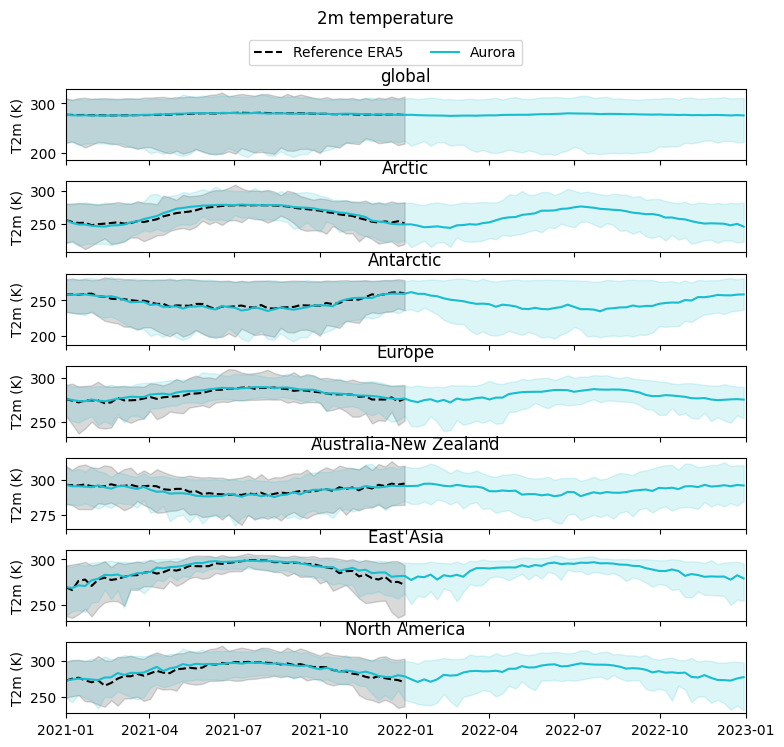

In [7]:
color = COLOR_MODEL.get(model_name, 'tab:blue')

# ERA5: extract the variable, selecting level if it is a pressure-level var
parts = var.rsplit('_', 1)
if len(parts) == 2 and parts[1].isdigit():
    era5_var, lev = parts[0], int(parts[1])
else:
    era5_var, lev = var, None

fig, axs = plt.subplots(len(list_areas), 1,
                         figsize=(8, 8), dpi=100, sharex=True)
fig.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.88, hspace=0.3)

for i, area_name in enumerate(list_areas):
    ax = axs[i]

    # ERA5 target
    era5_sel = ds_era5.sel(time=np.intersect1d(ds_era5.time.values, t_vec_target.values))
    if lev is not None:
        era5_sel = era5_sel.sel(level=lev)
    era5_box = select_box(area_name, era5_sel)
    target   = era5_box[era5_var].isel(time=range(0, era5_box.time.size, Rt))
    t_mean   = target.mean(dim=['latitude', 'longitude']).compute()
    t_min    = target.min( dim=['latitude', 'longitude']).compute()
    t_max    = target.max( dim=['latitude', 'longitude']).compute()

    ax.fill_between(t_mean.time.values, t_min, t_max, color='k', alpha=0.15)
    ax.plot(t_mean.time.values, t_mean, 'k--',
            label='Reference ERA5' if i == 0 else '')

    # Model prediction — level already dropped in all_pred
    pred_box = select_box(area_name, ds_pred)
    pred     = pred_box[var].isel(time=range(0, pred_box.time.size, Rt))
    p_mean   = pred.mean(dim=['latitude', 'longitude']).compute()
    p_min    = pred.min( dim=['latitude', 'longitude']).compute()
    p_max    = pred.max( dim=['latitude', 'longitude']).compute()

    ax.fill_between(p_mean.time.values, p_min, p_max, color=color, alpha=0.15)
    ax.plot(p_mean.time.values, p_mean, color=color,
            label=model_name if i == 0 else '')

    ax.set_title(area_name)
    short, unit = VAR_LABELS.get(var, (var, ""))
    ax.set_ylabel(f"{short} ({unit})")
    ax.set_xlim([np.datetime64('2021-01-01'), np.datetime64('2023-01-01')])

fig.suptitle(var.replace('_', ' '))
fig.legend(loc='upper center', ncols=2, bbox_to_anchor=(0.5, 0.95))
plt.show()